## Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    f1_score
)

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

### Load Dataset

In [3]:
df = pd.read_csv("complated_clean_data.csv")

df.head()

,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,...,region_Central,region_East,region_North,region_South,region_West,employment_type_Retired,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed
0,0.640070,2.544216,0.056847,-1.353085,0.264743,-0.744091,-1.080157,1.281490,-0.794708,2.379502,...,0,0,0,1,0,0,1,0,0,0
1,-0.702181,-0.527484,-0.510177,-0.281153,0.264743,-0.934479,-2.243812,-1.044769,0.447023,0.863791,...,1,0,0,0,0,0,1,0,0,0
2,-0.031055,-0.095225,0.785877,-1.081397,-0.884685,-0.281721,-0.830803,0.436257,1.688754,0.863791,...,0,1,0,0,0,0,1,0,0,0
3,-0.798056,-0.141232,-2.033039,0.385717,1.988886,2.288516,1.579625,-0.342629,0.447023,2.379502,...,0,0,1,0,0,0,0,0,0,1
4,-0.031055,-0.013765,0.866880,0.118969,0.264743,1.322977,1.247152,0.597326,-0.794708,0.863791,...,0,1,0,0,0,0,0,1,0,0


### Features and Target

In [4]:
X = df.drop("risk_status", axis=1)

y = df["risk_status"]

In [5]:
X = pd.get_dummies(X, drop_first=True)

### Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

### Train Model

In [7]:
lr = LogisticRegression(max_iter=1000,random_state=42)

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [8]:
y_pred = lr.predict(X_test)

### Evaluation

In [9]:
print("Baseline Logistic Regression")

print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision :", precision_score(y_test,y_pred))

print("Recall :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

Baseline Logistic Regression
Accuracy : 0.9989130434782608
Precision : 1.0
Recall : 0.990990990990991
F1 Score : 0.995475113122172


### Confusion Matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[809,   0],
       [  1, 110]])

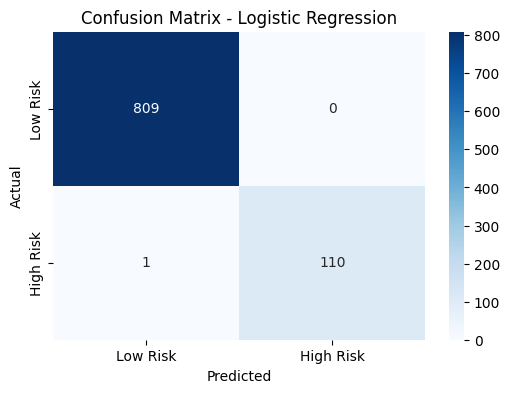

In [11]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Risk','High Risk'],
    yticklabels=['Low Risk','High Risk']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [12]:
from sklearn.metrics import classification_report

print("Baseline Logistic Regression")
print(classification_report(y_test, y_pred))

Baseline Logistic Regression
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       1.00      0.99      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



## Apply SMOTE

In [13]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

lr_smote = LogisticRegression(max_iter=1000,random_state=42)

lr_smote.fit(X_train_smote,y_train_smote)

y_pred_smote = lr_smote.predict(X_test)

In [14]:
print("Before SMOTE")
print(y_train.value_counts())


print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
risk_status
0.0    3234
1.0     446
Name: count, dtype: int64

After SMOTE
risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


## Apply ADASYN

In [15]:
adasyn = ADASYN(random_state=42)

X_train_ada, y_train_ada = adasyn.fit_resample(
    X_train,
    y_train
)

lr_ada = LogisticRegression(max_iter=1000,random_state=42)

lr_ada.fit(X_train_ada,y_train_ada)

y_pred_ada = lr_ada.predict(X_test)

In [16]:
print("Before ADASYN:")
print(y_train.value_counts())

print("\nAfter ADASYN:")
print(y_train_ada.value_counts())

Before ADASYN:
risk_status
0.0    3234
1.0     446
Name: count, dtype: int64

After ADASYN:
risk_status
0.0    3234
1.0    3198
Name: count, dtype: int64


### Comparison Table

In [17]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Logistic + SMOTE",
        "Logistic + ADASYN"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred_smote),
        accuracy_score(y_test,y_pred_ada)
    ],

    "Precision":[
        precision_score(y_test,y_pred),
        precision_score(y_test,y_pred_smote),
        precision_score(y_test,y_pred_ada)
    ],

    "Recall":[
        recall_score(y_test,y_pred),
        recall_score(y_test,y_pred_smote),
        recall_score(y_test,y_pred_ada)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred),
        f1_score(y_test,y_pred_smote),
        f1_score(y_test,y_pred_ada)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.998913,1.000000,0.990991,0.995475
1,Logistic + SMOTE,0.998913,1.000000,0.990991,0.995475
2,Logistic + ADASYN,0.996739,0.982143,0.990991,0.986547


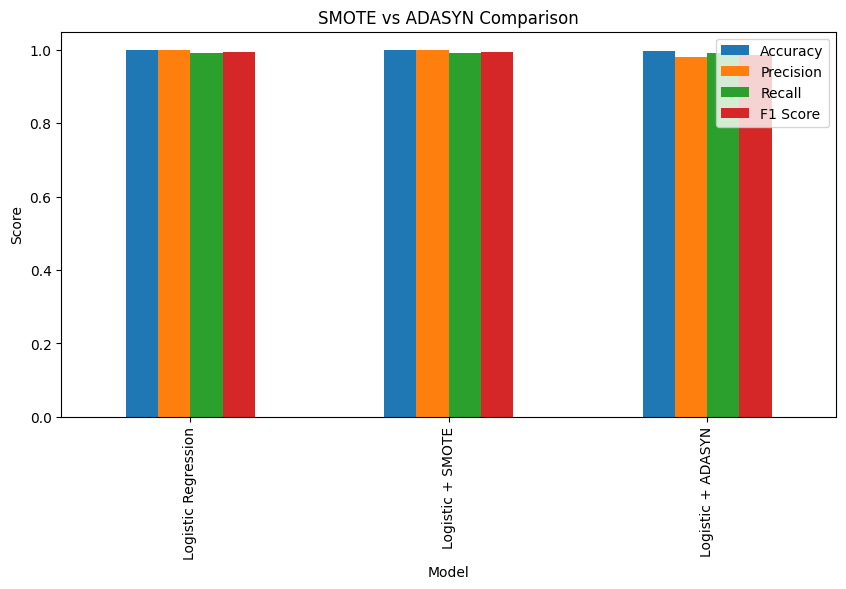

In [18]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("SMOTE vs ADASYN Comparison")
plt.ylabel("Score")

plt.show()

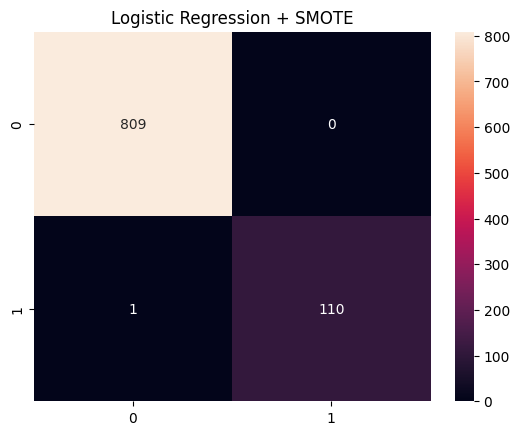

In [19]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

sns.heatmap(
    cm_smote,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression + SMOTE")
plt.show()

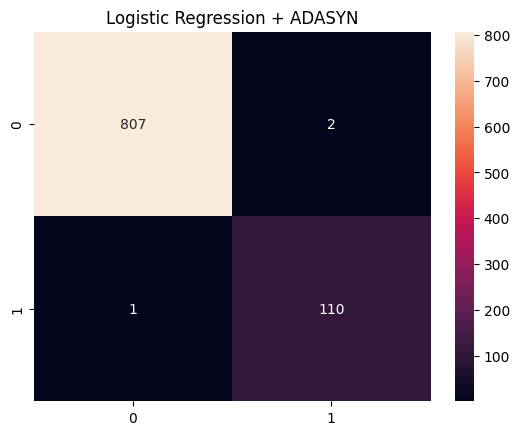

In [20]:
cm_ada = confusion_matrix(
    y_test,
    y_pred_ada
)

sns.heatmap(
    cm_ada,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression + ADASYN")
plt.show()

Both SMOTE and ADASYN were applied to address class imbalance in the dataset.

SMOTE generates synthetic minority samples uniformly, whereas ADASYN focuses on generating synthetic samples for difficult-to-learn minority observations.

After evaluation, the technique with the higher Recall and F1 Score was considered better for identifying High-Risk customers.

Since customer risk prediction prioritizes minimizing False Negatives, the model with the highest Recall was selected as the preferred imbalance-handling technique.